# LFPLoader Tutorial

This tutorial demonstrates how to use `neuro_py.io.loading.LFPLoader` to load LFP or DAT signals as a `nelpy.AnalogSignalArray`, including single-channel, multi-channel, and epoch-restricted usage.

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import nelpy as nel
import neuro_py as npy

from neuro_py.io import loading
from neuro_py.plotting.figure_helpers import set_plotting_defaults, set_size

set_plotting_defaults()

## 1) Set session path

Set `basepath` to a recording folder that contains your session files (`.xml`, `.lfp` or `.dat`, and optional event files).

In [2]:
basepath = r"U:\data\hpc_ctx_project\HP18\hp18_day85_20250713"

## 2) Inspect XML metadata

`loadXML` returns channel count and both LFP and DAT sampling rates.

In [3]:
nChannels, fs_lfp, fs_dat, shank_to_channel = loading.loadXML(basepath)
print(f"nChannels: {nChannels}")
print(f"fs_lfp:    {fs_lfp}")
print(f"fs_dat:    {fs_dat}")
print(f"n_shanks:  {len(shank_to_channel)}")

nChannels: 256
fs_lfp:    1250
fs_dat:    20000
n_shanks:  12


## 3) Load LFP/DAT with LFPLoader

`LFPLoader` returns an `nelpy.AnalogSignalArray` object.

When not specifiying a channel, `LFPLoader` will load all channels to a memory-mapped array that is accessed on demand, so it can be used even if the LFP/DAT files are too large to fit in memory.

In [4]:
# Load full LFP file
lfp_obj = loading.LFPLoader(basepath, ext="lfp")
print(type(lfp_obj))
print(lfp_obj)
print("data shape:", lfp_obj.data.shape)

<class 'neuro_py.io.loading.LFPLoader'>
<LFPLoader at 0x18ece52f110: 256 signals> for a total of 9:10:642 minutes
data shape: (256, 688304)


In [5]:
# Load DAT as AnalogSignalArray using fs_dat from XML
dat_obj = loading.LFPLoader(basepath, ext="dat")
print(type(dat_obj))
print(dat_obj)
print("data shape:", dat_obj.data.shape)

<class 'neuro_py.io.loading.LFPLoader'>
<LFPLoader at 0x18ecf8e4cd0: 256 signals> for a total of 9:10:643 minutes
data shape: (256, 11012864)


## 4) Single and multi-channel loading

You can pass one channel (`int`) or many channels (`list`).


In [62]:
# Example channel IDs
brain_regions = npy.io.load_brain_regions(basepath, out_format="DataFrame")

ripple_channel = brain_regions.query("region=='CA1so'").channels.iloc[0]
sharp_wave_channel = brain_regions.query("region=='CA1sr'").channels.iloc[0]

single_ch = loading.LFPLoader(basepath, channels=ripple_channel, ext="lfp")
multi_ch = loading.LFPLoader(
    basepath, channels=[ripple_channel, sharp_wave_channel], ext="lfp"
)

print("single channel shape:", single_ch.data.shape)
print("multi channel shape: ", multi_ch.data.shape)

single channel shape: (1, 688304)
multi channel shape:  (2, 688304)


## 5) Epoch-restricted loading

Restrict loaded data to a time interval using `epoch`.

In [8]:
epoch_df = loading.load_epoch(basepath)
epoch_df.head()

,name,startTime,stopTime,environment,manipulation,behavioralParadigm,stimuli,notes,basepath
0,hp18_probe_250713_091741,0,550.6432,cheeseboard,NaN,NaN,NaN,NaN,U:\data\hpc_ctx_project\HP18\hp18_day85_20250713


In [ ]:
# Restrict to first 5 seconds of the first epoch
t0 = float(epoch_df.startTime.iloc[0])
restricted_epoch = np.array([t0, t0 + 5.0])

lfp_restricted = loading.LFPLoader(
    basepath,
    channels=[ripple_channel, sharp_wave_channel],
    ext="lfp",
    epoch=restricted_epoch,
)

print(lfp_restricted.data.shape)
print(lfp_restricted.abscissa_vals.min(), lfp_restricted.abscissa_vals.max())

(2, 6251)
0.0 5.0


## 6) Basic plotting

Plot two channels in a short time window.

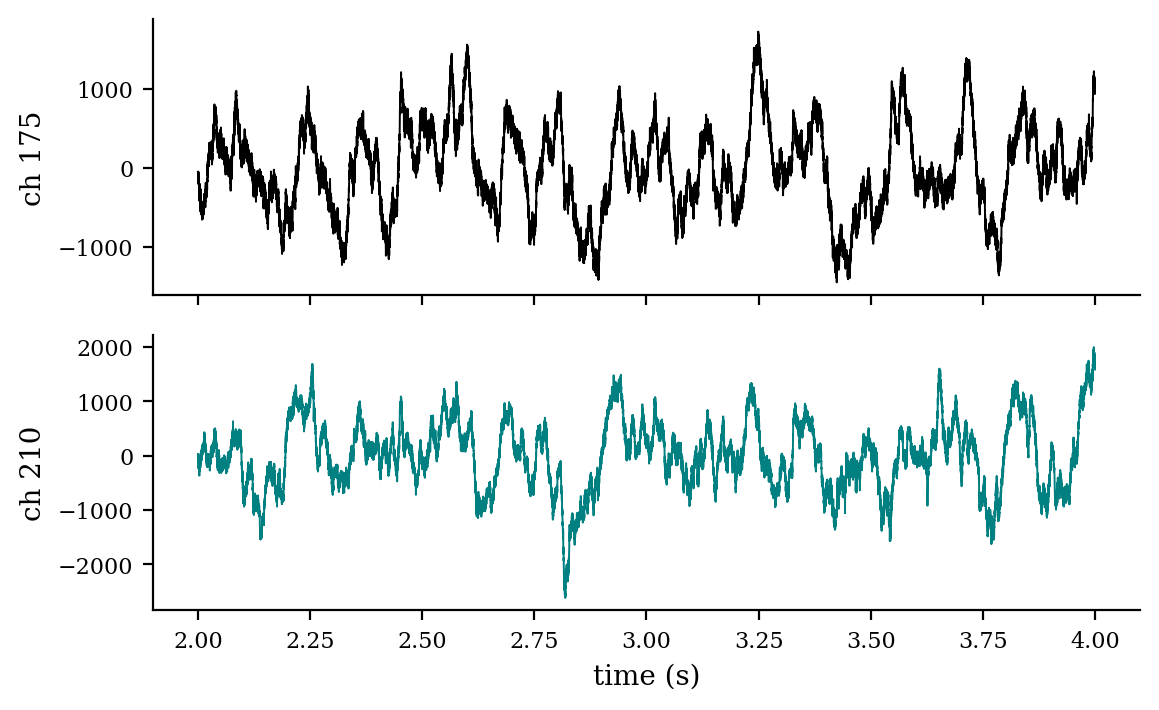

In [10]:
sig = loading.LFPLoader(
    basepath, channels=[ripple_channel, sharp_wave_channel], ext="dat"
)
ts = sig.abscissa_vals

window = (ts >= ts[0] + 2.0) & (ts <= ts[0] + 4.0)

fig, ax = plt.subplots(
    2, 1, figsize=set_size("thesis", fraction=1.0, subplots=(1, 1.0)), sharex=True
)
ax[0].plot(ts[window], sig.data[0, window], color="k", lw=0.7)
ax[1].plot(ts[window], sig.data[1, window], color="teal", lw=0.7)
ax[0].set_ylabel(f"ch {ripple_channel}")
ax[1].set_ylabel(f"ch {sharp_wave_channel}")
ax[1].set_xlabel("time (s)")
sns.despine()
plt.tight_layout()
plt.show()

## 7) More advanced plotting



### Plotting raw data from every channel around a ripple event.

Text(272.86125000000004, -46500, '3000 uV')

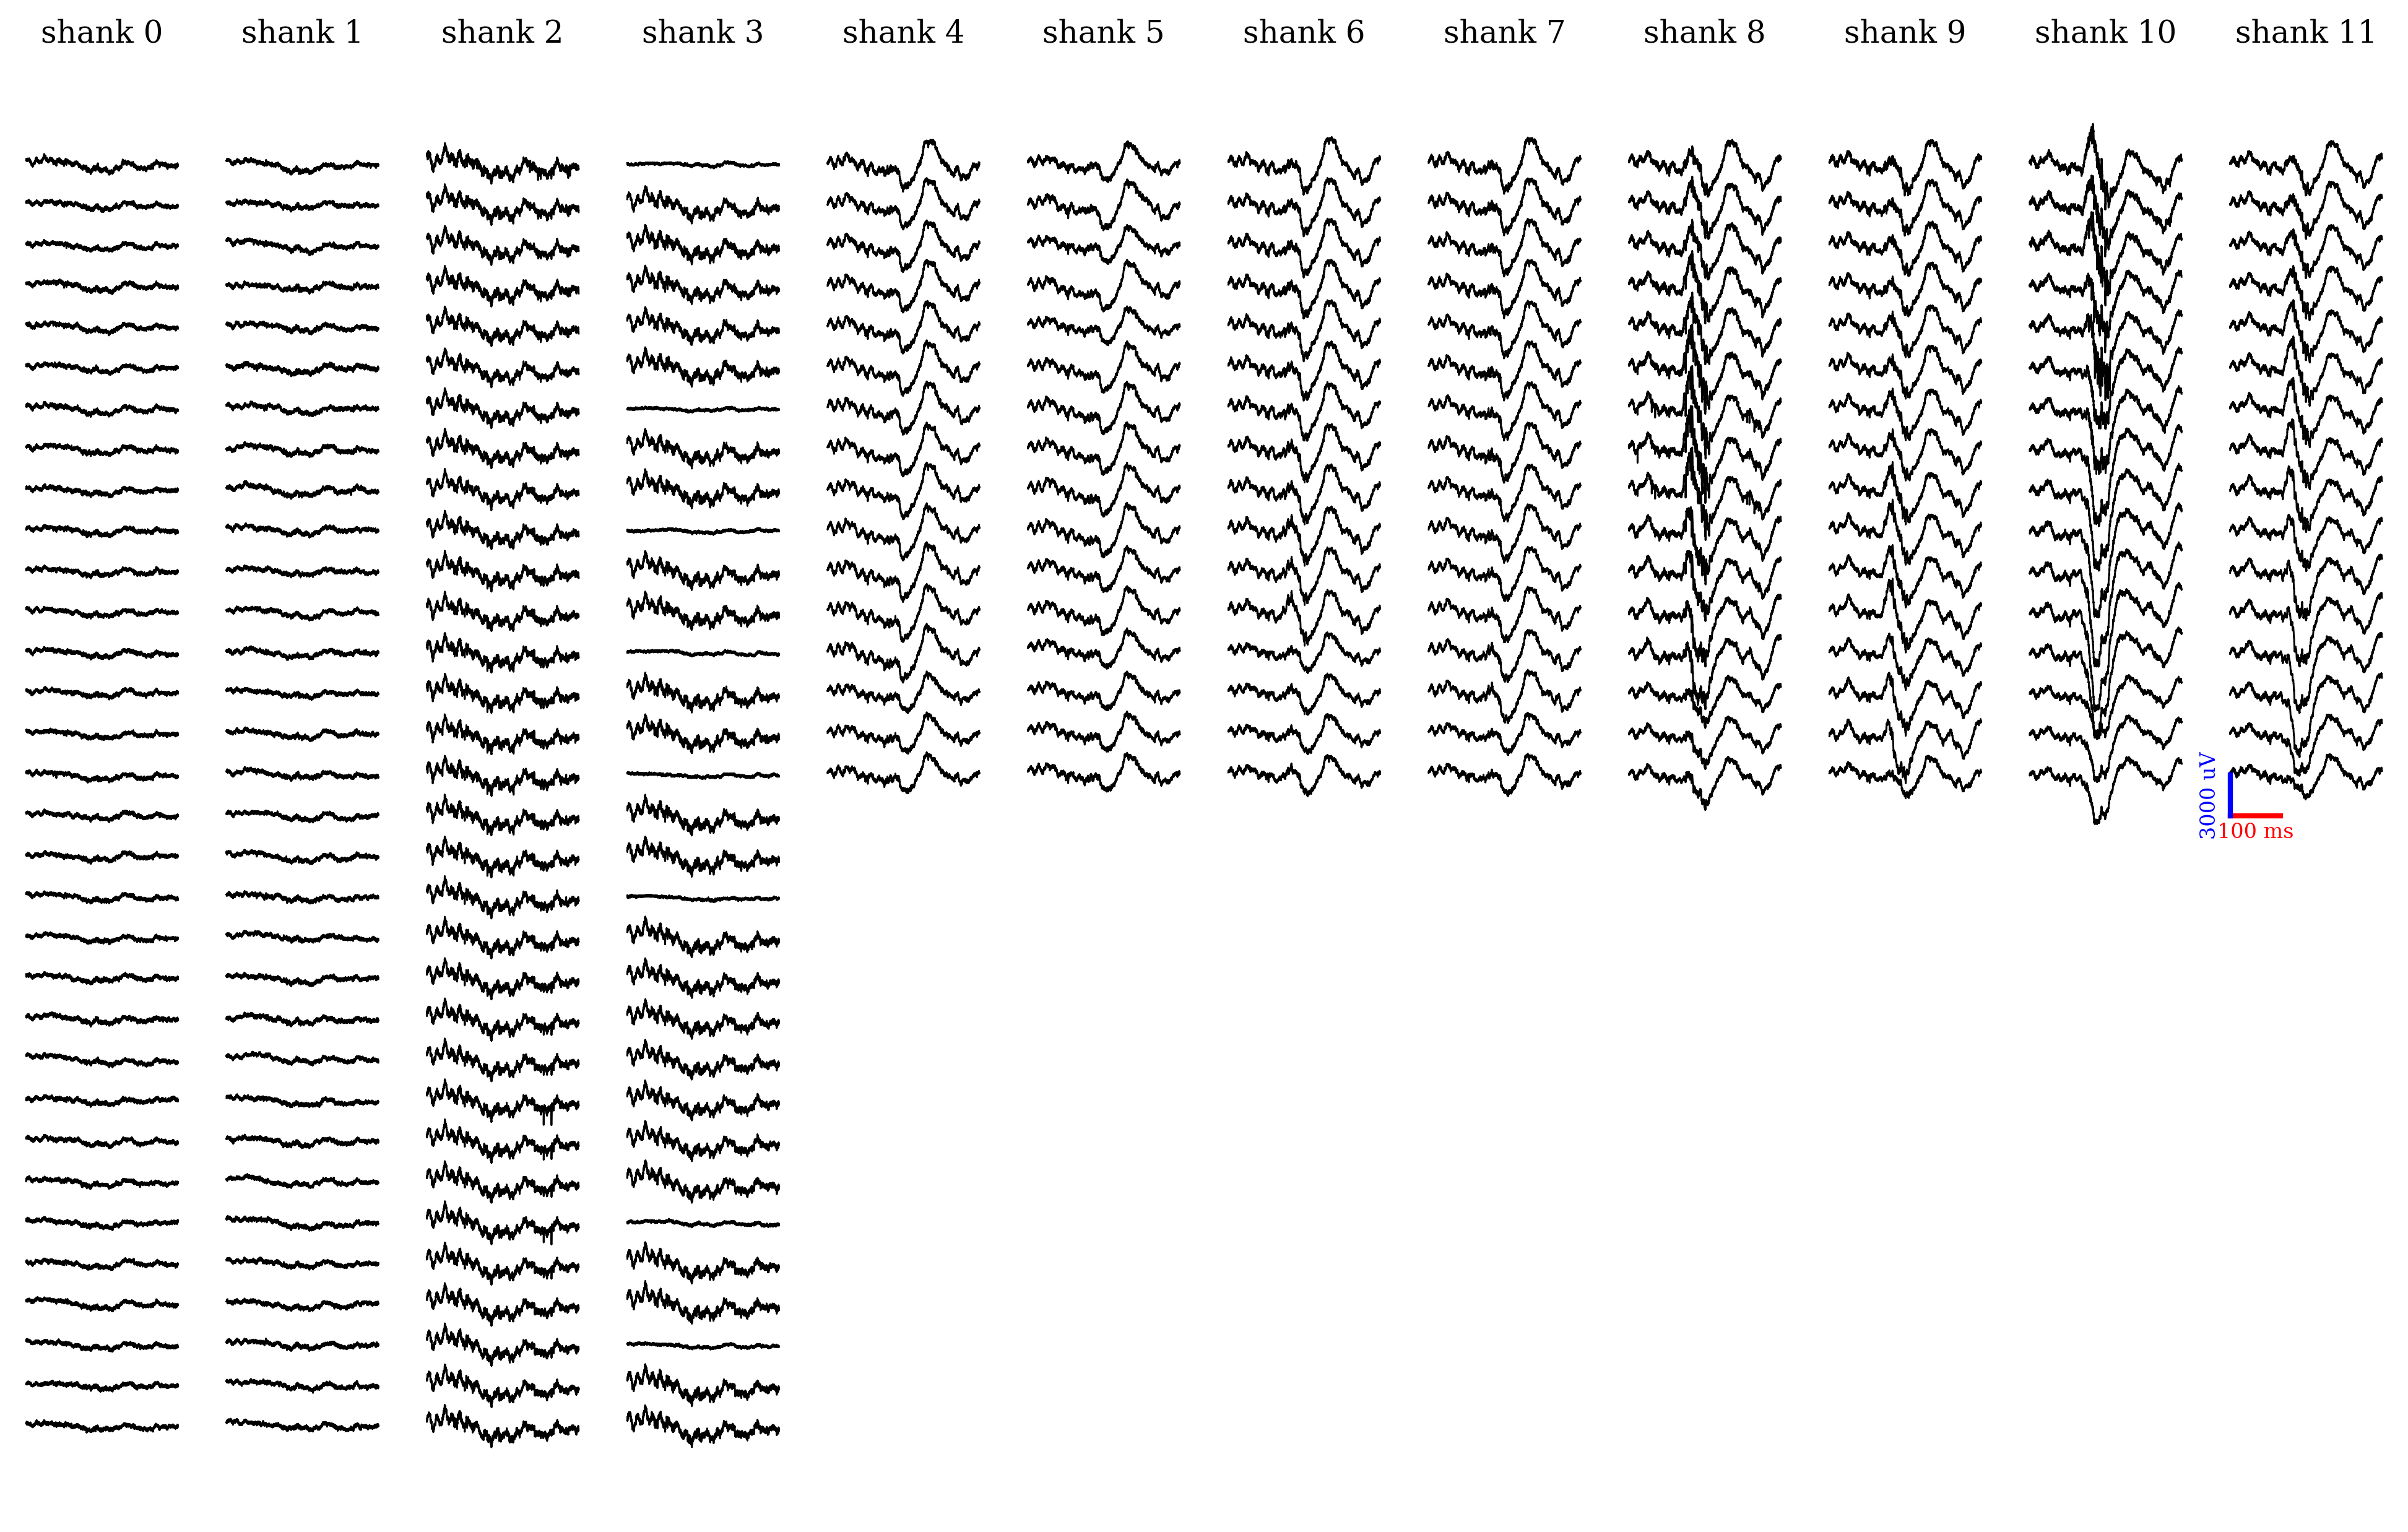

In [11]:
ripples = npy.io.load_ripples_events(basepath)
sig = loading.LFPLoader(basepath, ext="dat")

ripple_n = 28
window = (ts >= ripples.peaks[ripple_n] - 0.150) & (
    ts <= ripples.peaks[ripple_n] + 0.150
)

fig, ax = plt.subplots(
    1,
    len(sig.shank_to_channel.keys()),
    figsize=set_size("paper", fraction=2, subplots=(1, 1)),
    sharex=True,
    sharey=True,
    dpi=150,
)
for i, (shank, channel) in enumerate(sig.shank_to_channel.items()):
    offsets = np.arange(len(channel)) * 3000
    ax[i].plot(
        ts[window], sig.data[:, window][channel, :].T - offsets, color="k", lw=0.7
    )
    ax[i].set_title(f"shank {shank}")
    ax[i].set_xlabel("time (s)")
    ax[i].axis("off")
# add scale bar
ax[i].plot(
    [ts[window][0], ts[window][0] + 0.1],
    [-offsets[-1] - 3000, -offsets[-1] - 3000],
    color="red",
    lw=2,
    label="100 ms",
)
# add text label for scale bar
ax[i].text(
    ts[window][0] + 0.05,
    -offsets[-1] - 3500,
    "100 ms",
    color="red",
    ha="center",
    va="top",
    fontsize=8,
)

# to scale bar add amplitude label
ax[i].plot(
    [ts[window][0], ts[window][0]],
    [-offsets[-1] - 3000, -offsets[-1]],
    color="blue",
    lw=2,
    label="3000 uV",
)
ax[i].text(
    ts[window][0] - 0.02,
    -offsets[-1] - 1500,
    "3000 uV",
    color="blue",
    ha="right",
    va="center",
    fontsize=8,
    rotation=90,
)


### Plotting raw data from every channel from a particular shank around a ripple event.

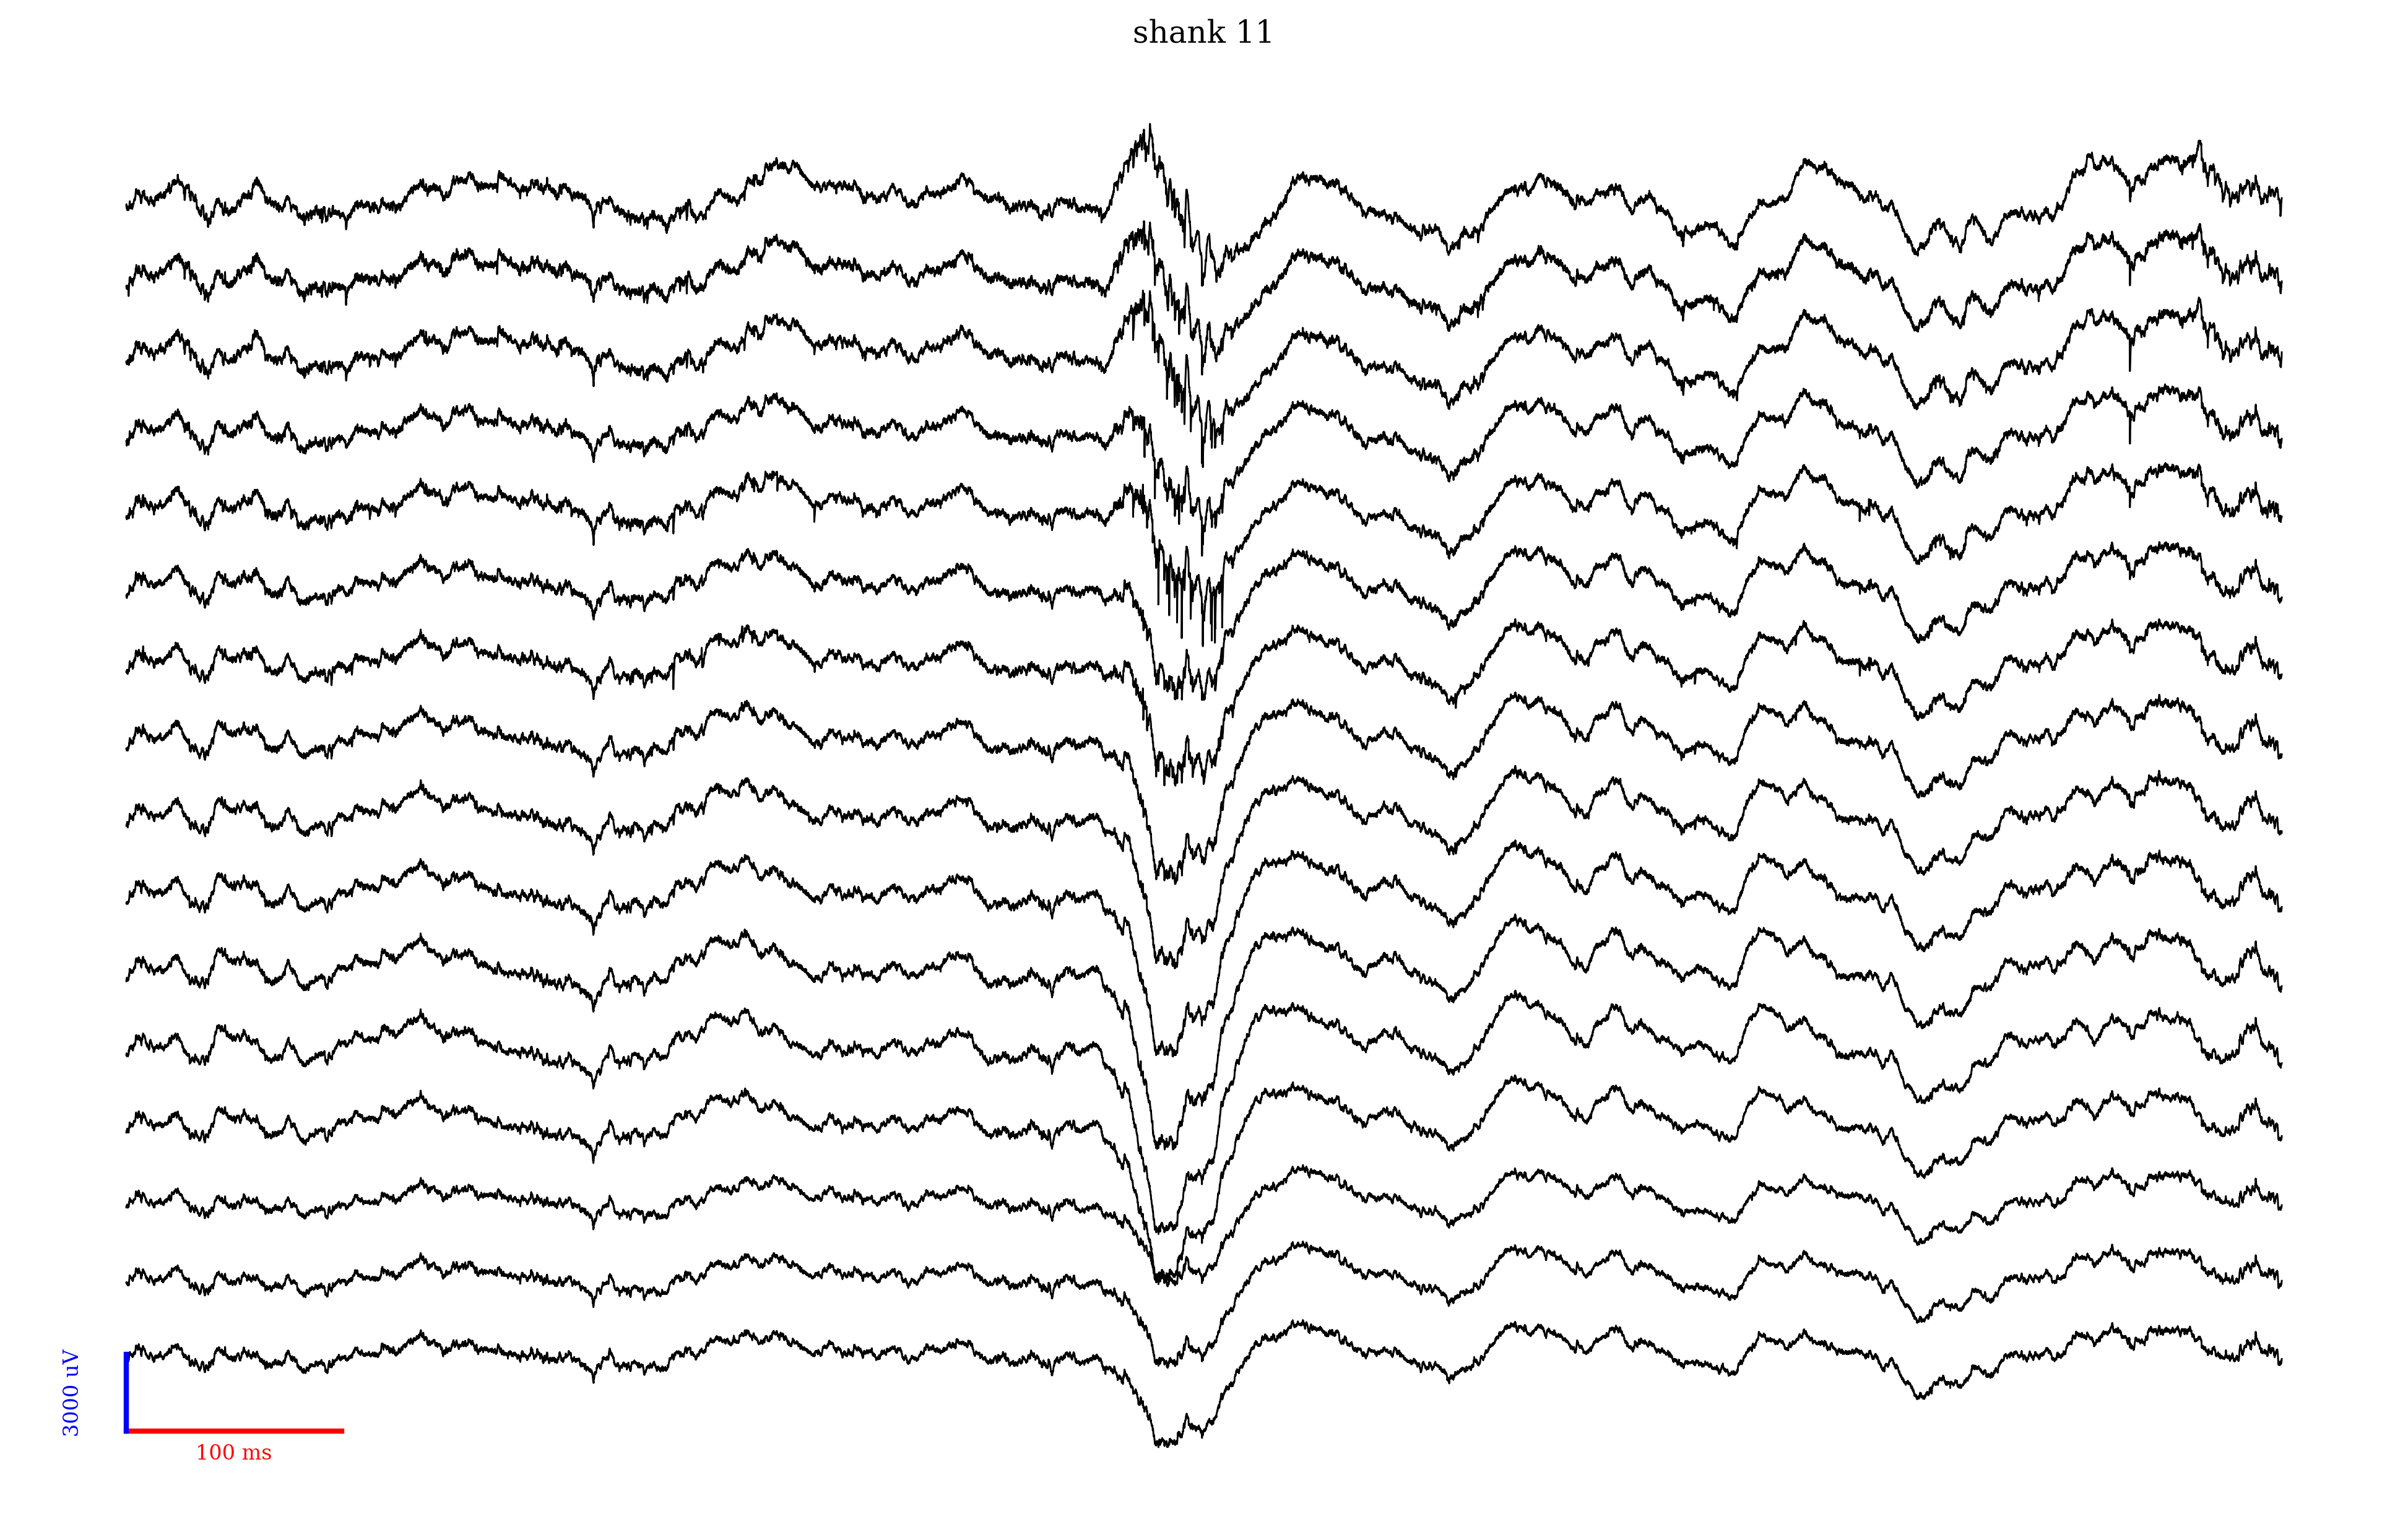

In [ ]:
ripples = npy.io.load_ripples_events(basepath)
sig = loading.LFPLoader(basepath, ext="dat")

ripple_n = 28
window = (ts >= ripples.peaks[ripple_n] - 0.5) & (ts <= ripples.peaks[ripple_n] + 0.5)

fig, ax = plt.subplots(
    1,
    1,
    figsize=set_size("paper", fraction=2, subplots=(1, 1)),
    sharex=True,
    sharey=True,
    dpi=150,
)

channel = sig.shank_to_channel.get(10)
offsets = np.arange(len(channel)) * 3000
ax.plot(ts[window], sig.data[:, window][channel, :].T - offsets, color="k", lw=0.7)
ax.set_title(f"shank {shank}")
ax.set_xlabel("time (s)")
ax.axis("off")
# add scale bar
ax.plot(
    [ts[window][0], ts[window][0] + 0.1],
    [-offsets[-1] - 3000, -offsets[-1] - 3000],
    color="red",
    lw=2,
    label="100 ms",
)
# add text label for scale bar
ax.text(
    ts[window][0] + 0.05,
    -offsets[-1] - 3500,
    "100 ms",
    color="red",
    ha="center",
    va="top",
    fontsize=8,
)

# to scale bar add amplitude label
ax.plot(
    [ts[window][0], ts[window][0]],
    [-offsets[-1] - 3000, -offsets[-1]],
    color="blue",
    lw=2,
    label="3000 uV",
)
ax.text(
    ts[window][0] - 0.02,
    -offsets[-1] - 1500,
    "3000 uV",
    color="blue",
    ha="right",
    va="center",
    fontsize=8,
    rotation=90,
)
plt.show()

## 8) Frequency-domain helpers

`LFPLoader` provides convenience methods for phase and instantaneous frequency estimates.

In [13]:
theta_sig = loading.LFPLoader(basepath, channels=ripple_channel, ext="lfp")
phase = theta_sig.get_phase(band2filter=[6, 12], ford=3)
filt_sig, phase2, amp, amp_filt, inst_freq = theta_sig.get_freq_phase_amp(
    band2filter=[6, 12],
    ford=3,
    kernel_size=13,
)

print("phase shape:       ", phase.shape)
print("filtered shape:    ", filt_sig.shape)
print("inst freq shape:   ", inst_freq.shape)

phase shape:        (1, 688304)
filtered shape:     (1, 688304)
inst freq shape:    (1, 688304)


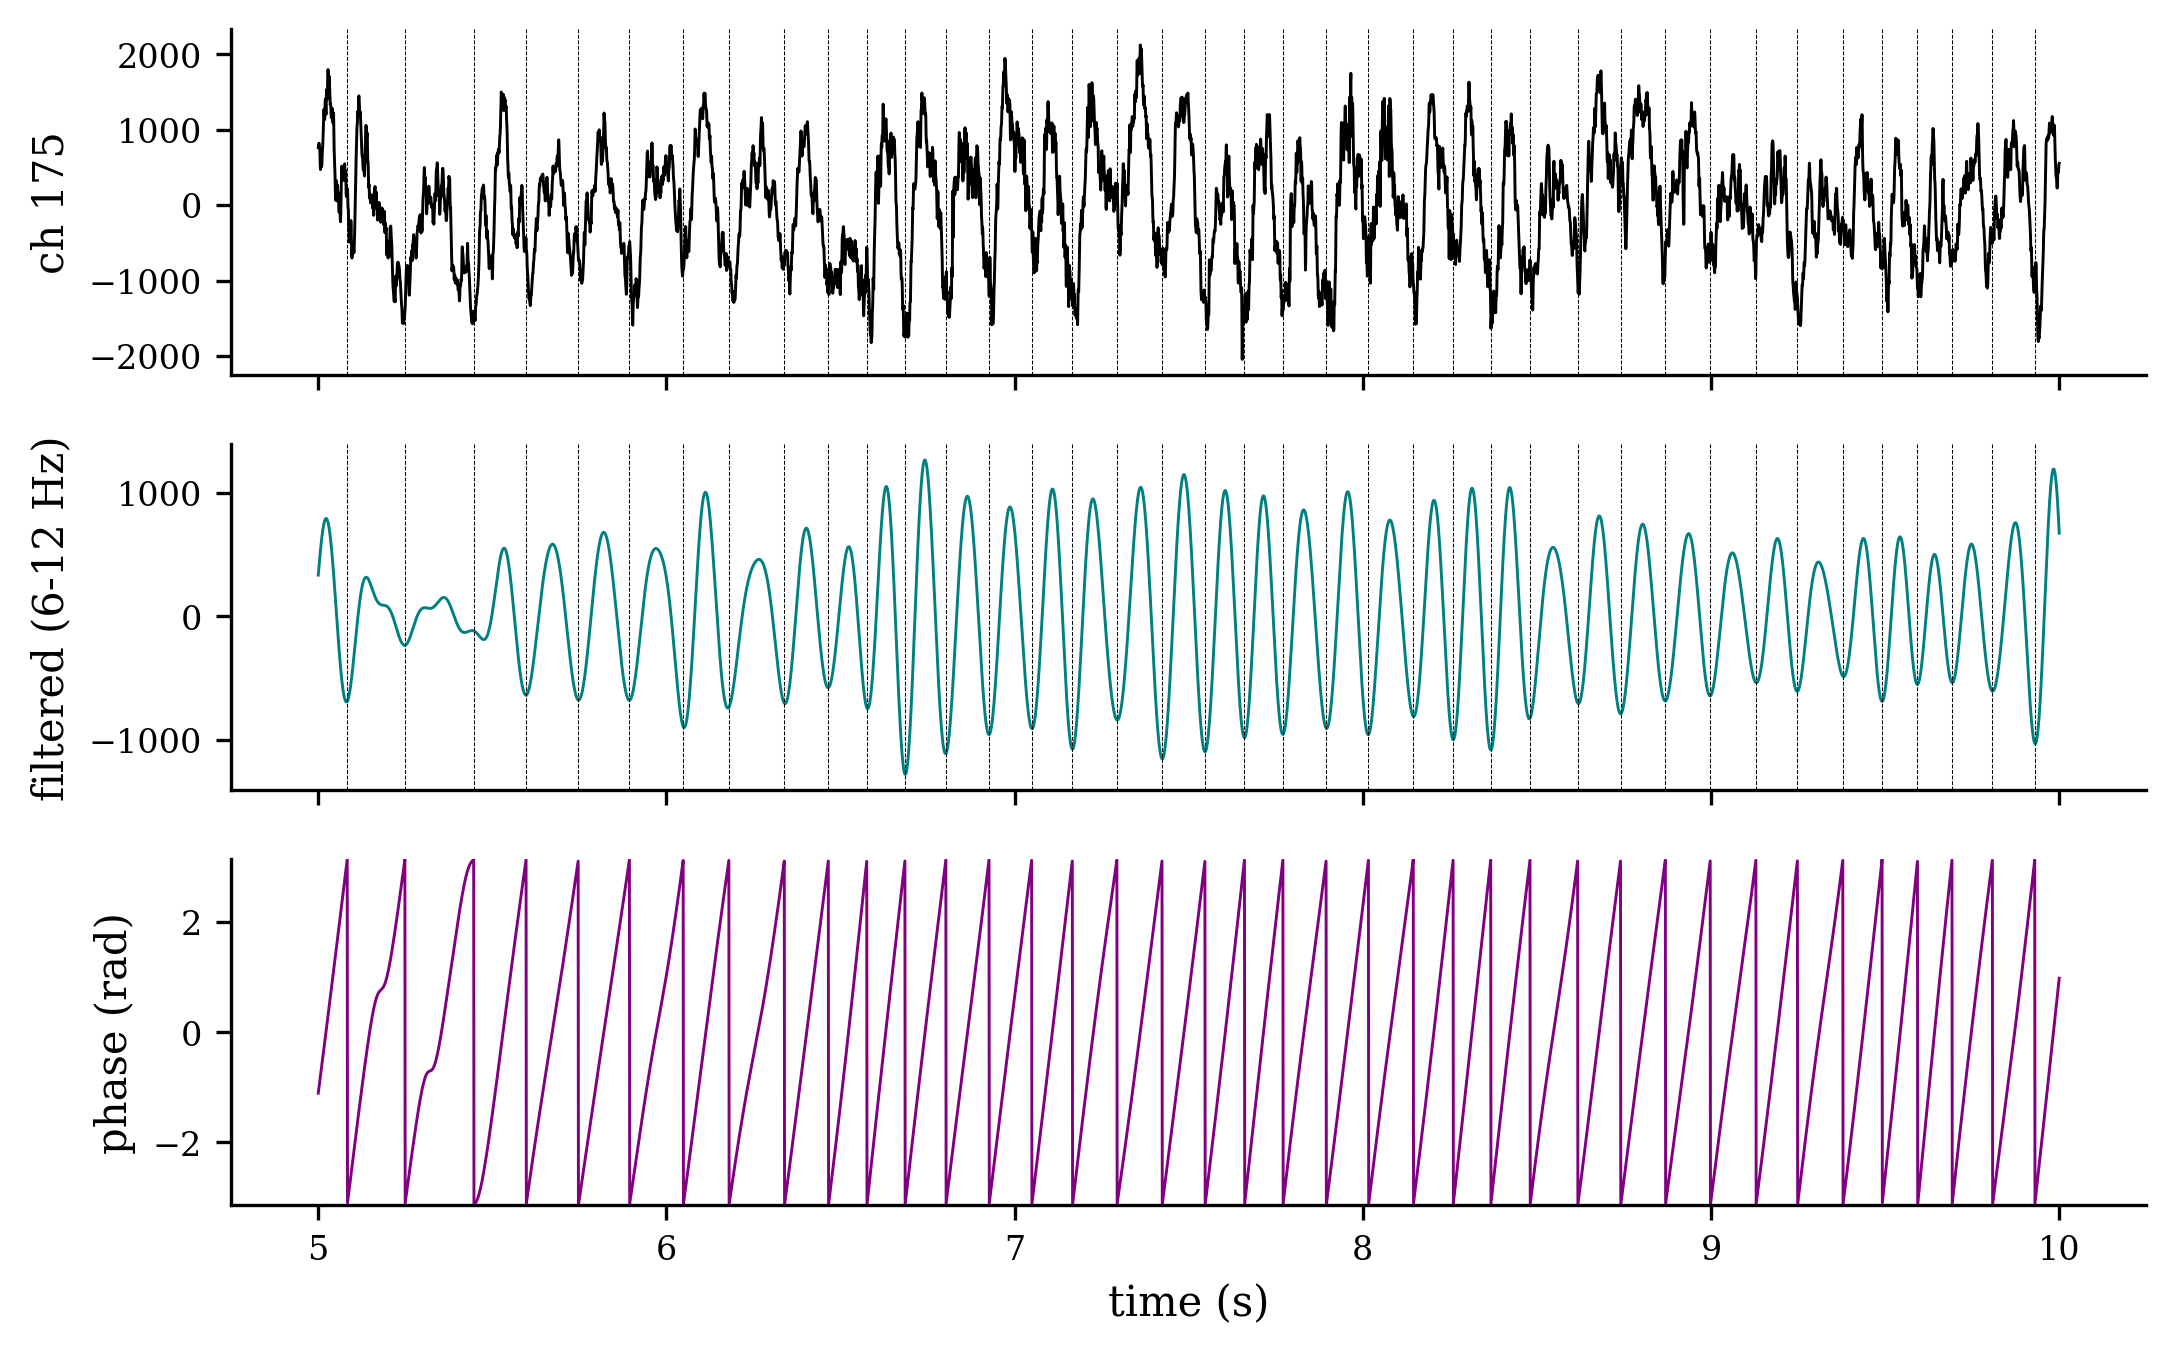

In [ ]:
from scipy.signal import find_peaks

window = (theta_sig.abscissa_vals >= 5) & (theta_sig.abscissa_vals <= 10)

fig, ax = plt.subplots(
    3, 1, figsize=set_size("paper", fraction=1, subplots=(3, 3)), sharex=True, dpi=150
)

ax[0].plot(
    theta_sig.abscissa_vals[window], theta_sig.data[0, window], color="k", lw=0.7
)
ax[0].set_ylabel(f"ch {ripple_channel}")
ax[1].plot(theta_sig.abscissa_vals[window], filt_sig[0, window], color="teal", lw=0.7)
ax[1].set_ylabel("filtered (6-12 Hz)")
ax[2].plot(theta_sig.abscissa_vals[window], phase[0, window], color="purple", lw=0.7)
ax[2].set_ylabel("phase (rad)")
ax[2].set_xlabel("time (s)")
ax[2].set_ylim(-np.pi, np.pi)
peaks, _ = find_peaks(phase[0, window], height=0)
for ax_ in ax[:2]:
    for peak in peaks:
        ax_.axvline(theta_sig.abscissa_vals[window][peak], color="k", lw=0.25, ls="--")
sns.despine()